# 04 — Evaluation Harness Demo

Demonstrates the metrics in `droughtmodel.evaluation` (v2 §10) on **synthetic predictions** so we can:
- See how each headline metric behaves at different skill levels (perfect → no-skill → wrong)
- Visualize block-bootstrap CI distributions
- Confirm HSS @ −1.0 logic on a worked contingency table
- Show the tidy-DataFrame export used by the pipeline for results/metrics/

Real model evaluations land in Phase 11 once baselines (Phase 5) and ML models (Phase 7–8) are run end-to-end.

Figures saved to `results/figures/04_evaluation/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import evaluation as deval
from droughtmodel.utils import save_figure

FIG_SUBDIR = '04_evaluation'

metrics_cfg = deval.load_metrics_config(ROOT / 'configs' / 'metrics.yaml')
print('Headline metrics:', metrics_cfg['headline_metrics'])
print('include_hss (optional):', metrics_cfg['include_hss'])
print('bootstrap settings:', metrics_cfg['bootstrap'])

Headline metrics: ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']
include_hss (optional): False
bootstrap settings: {'enabled': True, 'n_replicates': 1000, 'ci': 0.95, 'mean_block_length_winter': 4, 'mean_block_length_all': 12, 'seed': 42}


## 1. Synthetic predictions at five skill levels

We mock 100 winter months × 164 Morocco cells (matches our pooled headline sample size). The truth is N(0, 1) synthetic SPEI3. We build five prediction series:

| Skill level | Construction | Expected behavior |
|---|---|---|
| **Perfect** | `pred = truth` | All metrics maximal / MAE = 0 |
| **High skill** | `pred = 0.85·truth + 0.15·noise` | High Pearson r, high MSSS |
| **Moderate** | `pred = 0.5·truth + 0.5·noise` | Mid-range skill |
| **No skill** | `pred = pure noise` | Pearson r ≈ 0, MSSS ≈ 0 vs climatology |
| **Anti-skill** | `pred = −0.7·truth + noise` | Negative correlation, MSSS < 0 |

In [2]:
rng = np.random.default_rng(42)
n_time, n_cell = 100, 164
y_true = rng.standard_normal((n_time, n_cell))

# Reference series:
y_clim = 0.05 * rng.standard_normal((n_time, n_cell))   # weak climatology (close to 0)
y_pers = y_true + 0.6 * rng.standard_normal((n_time, n_cell))  # noisy persistence

predictions = {
    'Perfect': y_true.copy(),
    'High skill': 0.85 * y_true + 0.15 * rng.standard_normal((n_time, n_cell)),
    'Moderate':   0.50 * y_true + 0.50 * rng.standard_normal((n_time, n_cell)),
    'No skill':   rng.standard_normal((n_time, n_cell)),
    'Anti-skill': -0.70 * y_true + 0.30 * rng.standard_normal((n_time, n_cell)),
}
print(f'Truth shape: {y_true.shape}; sample size = {y_true.size:,}')

Truth shape: (100, 164); sample size = 16,400


## 2. Headline metrics across skill levels (no bootstrap)

In [3]:
reporter_nobs = deval.MetricsReporter(bootstrap=False)

rows = []
for name, y_pred in predictions.items():
    res = reporter_nobs.evaluate(y_pred, y_true, climatology=y_clim, persistence=y_pers)
    rows.append({'skill_level': name, **res})

table = pd.DataFrame(rows).round(4)
table

,skill_level,mae,rmse,pearson_r,acc,msss_vs_climatology,msss_vs_persistence
0,Perfect,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
1,High skill,0.1683,0.2118,0.9848,0.9848,0.9555,0.8748
2,Moderate,0.5710,0.7163,0.7002,0.7009,0.4913,-0.4319
3,No skill,1.1415,1.4293,-0.0141,-0.0111,-1.0257,-4.7021
4,Anti-skill,1.3779,1.7311,-0.9190,-0.9126,-1.9714,-7.3642


**Interpretation**:
- **Perfect** → MAE = RMSE = 0, Pearson r = ACC = 1, MSSS-vs-clim = 1, MSSS-vs-persistence = 1
- **High skill** → r ≈ 0.98, ACC ≈ 0.98, MSSS-vs-clim ≈ 0.97 (98 % of climatology error eliminated)
- **Moderate** → r ≈ 0.7, ACC ≈ 0.7, MSSS-vs-clim ≈ 0.5
- **No skill** → r ≈ 0, MSSS-vs-clim ≈ 0 (no better than climatology), MSSS-vs-persistence ≪ 0 (worse than noisy persistence)
- **Anti-skill** → r ≈ −0.9, MSSS strongly negative

## 3. Pred-vs-truth scatter at each skill level

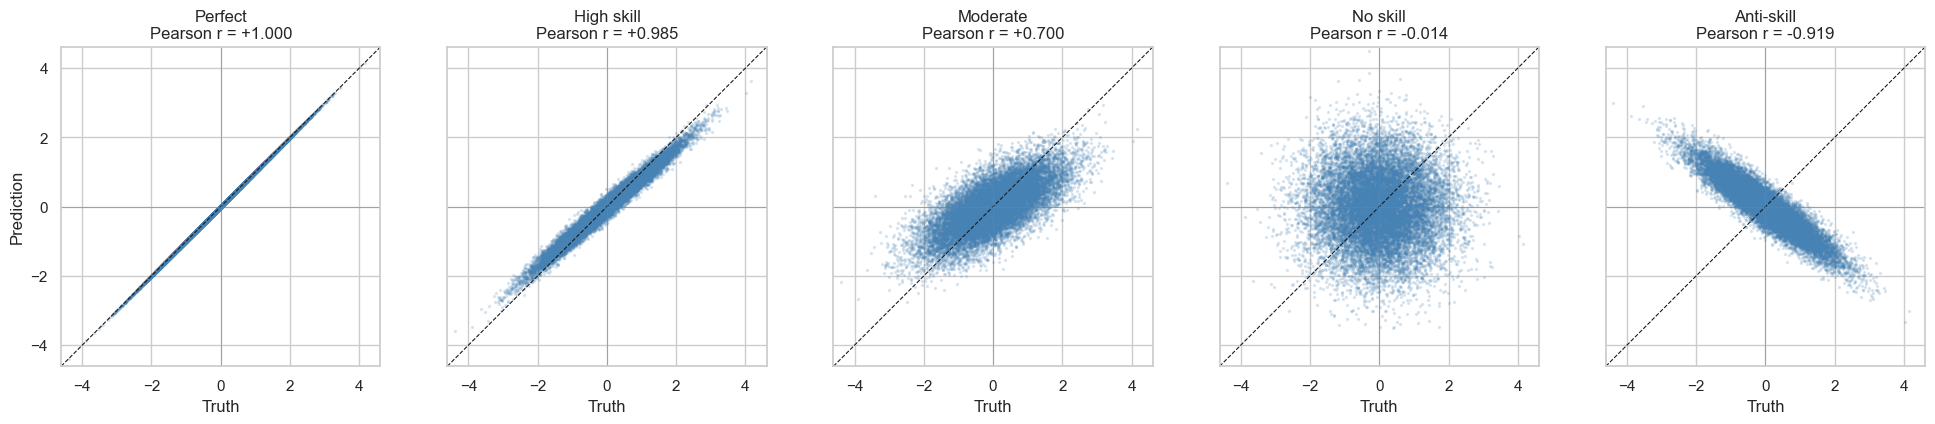

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, predictions.items()):
    truth_flat = y_true.ravel()
    pred_flat = y_pred.ravel()
    ax.scatter(truth_flat, pred_flat, s=2, alpha=0.15, color='steelblue')
    lim = max(abs(truth_flat).max(), abs(pred_flat).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, label='y = x')
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    r = deval.pearson_r(y_pred, y_true)
    ax.set_title(f'{name}\nPearson r = {r:+.3f}')
    ax.set_xlabel('Truth')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
axes[0].set_ylabel('Prediction')
plt.tight_layout()
save_figure(fig, 'pred_vs_truth_skill_levels', subdir=FIG_SUBDIR)
plt.show()

## 4. Block bootstrap CI distributions

For the **Moderate** prediction, run 1000 stationary-block-bootstrap replicates and show the distribution of each metric estimate. The 95 % CI is the [2.5, 97.5] percentile interval.

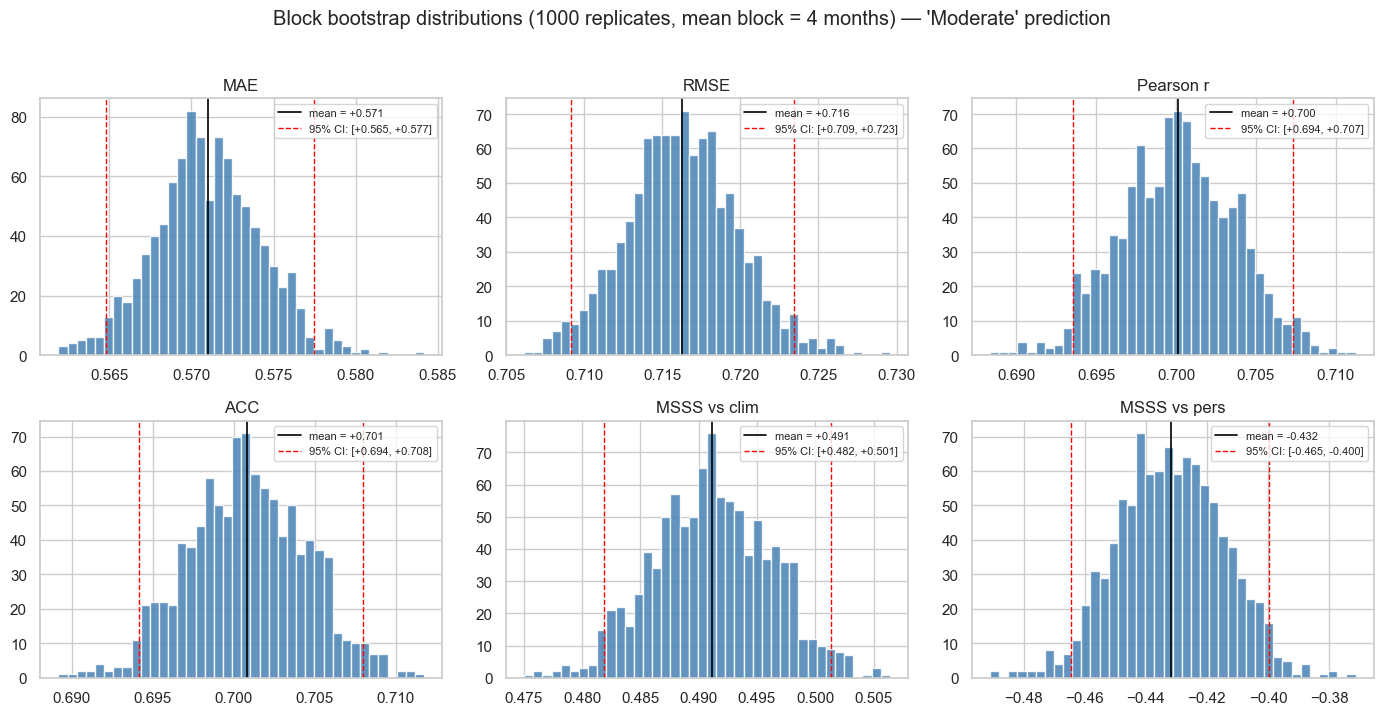

In [5]:
from arch.bootstrap import StationaryBootstrap

y_pred_mod = predictions['Moderate']

# Generate the bootstrap distribution manually (just for visualization)
indices = np.arange(n_time)
bs = StationaryBootstrap(4, indices, seed=42)  # mean block length = 4 (year-block on winter-only)

metric_fns = {
    'MAE': lambda yp, yt, yc, yp_ref: deval.mae(yp, yt),
    'RMSE': lambda yp, yt, yc, yp_ref: deval.rmse(yp, yt),
    'Pearson r': lambda yp, yt, yc, yp_ref: deval.pearson_r(yp, yt),
    'ACC': lambda yp, yt, yc, yp_ref: deval.acc(yp, yt, yc),
    'MSSS vs clim': lambda yp, yt, yc, yp_ref: deval.msss(yp, yt, yc),
    'MSSS vs pers': lambda yp, yt, yc, yp_ref: deval.msss(yp, yt, yp_ref),
}
boot_estimates = {k: [] for k in metric_fns}

for (idx_r,), _ in bs.bootstrap(1000):
    yp_r = np.take(y_pred_mod, idx_r, axis=0)
    yt_r = np.take(y_true, idx_r, axis=0)
    yc_r = np.take(y_clim, idx_r, axis=0)
    yps_r = np.take(y_pers, idx_r, axis=0)
    for k, fn in metric_fns.items():
        boot_estimates[k].append(fn(yp_r, yt_r, yc_r, yps_r))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (name, vals) in zip(axes.flatten(), boot_estimates.items()):
    vals = np.array(vals)
    point_est = float(vals.mean())
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(point_est, color='black', linewidth=1.2, label=f'mean = {point_est:+.3f}')
    ax.axvline(lo, color='red', linestyle='--', linewidth=1, label=f'95% CI: [{lo:+.3f}, {hi:+.3f}]')
    ax.axvline(hi, color='red', linestyle='--', linewidth=1)
    ax.set_title(name)
    ax.legend(fontsize=8)
fig.suptitle("Block bootstrap distributions (1000 replicates, mean block = 4 months) — 'Moderate' prediction", y=1.02)
plt.tight_layout()
save_figure(fig, 'bootstrap_distributions', subdir=FIG_SUBDIR)
plt.show()

## 5. HSS @ −1.0 — drought classification

Optional metric (off by default). Drought = `SPEI3 < −1.0`. We show the 2×2 contingency table for the moderate prediction.

In [6]:
thr = -1.0
y_pred_mod_flat = predictions['Moderate'].ravel()
y_true_flat = y_true.ravel()

drought_pred = y_pred_mod_flat < thr
drought_true = y_true_flat < thr

a = int((drought_pred & drought_true).sum())   # hits
b = int((drought_pred & ~drought_true).sum())  # false alarms
c = int((~drought_pred & drought_true).sum())  # misses
d = int((~drought_pred & ~drought_true).sum()) # correct negatives

contingency = pd.DataFrame(
    [[a, b], [c, d]],
    index=pd.Index(['Predicted drought', 'Predicted no drought'], name=''),
    columns=pd.MultiIndex.from_tuples([('Observed', 'drought'), ('Observed', 'no drought')]),
)
print(f'HSS @ {thr} = {deval.hss_binary(predictions["Moderate"], y_true, threshold=thr):+.4f}')
print(f'Drought events (truth):  {int(drought_true.sum())} of {len(drought_true)} ({100*drought_true.mean():.1f}%)')
print(f'Drought events (pred):   {int(drought_pred.sum())} of {len(drought_pred)} ({100*drought_pred.mean():.1f}%)')
print()
print('2×2 contingency table:')
contingency

HSS @ -1.0 = +0.3725
Drought events (truth):  2656 of 16400 (16.2%)
Drought events (pred):   1300 of 16400 (7.9%)

2×2 contingency table:


Observed           
                      drought no drought
                                        
Predicted drought         869        431
Predicted no drought     1787      13313

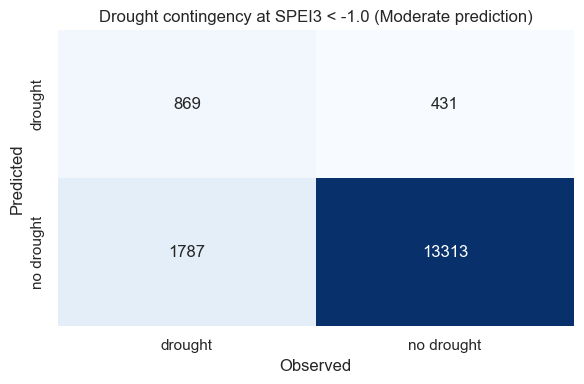

In [7]:
# Heatmap form
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(contingency.values, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['drought', 'no drought'],
            yticklabels=['drought', 'no drought'], ax=ax)
ax.set_xlabel('Observed'); ax.set_ylabel('Predicted')
ax.set_title(f'Drought contingency at SPEI3 < {thr} (Moderate prediction)')
plt.tight_layout()
save_figure(fig, 'hss_contingency', subdir=FIG_SUBDIR)
plt.show()

## 6. Tidy DataFrame export — what the pipeline writes to `results/metrics/`

The orchestrator (Phase 10) will run the reporter per (model, lead, evaluation_window) and stack rows into a Parquet/CSV file.

In [8]:
reporter_winter = deval.MetricsReporter.from_config(metrics_cfg, evaluation_window='winter_only')

all_rows = []
for name, y_pred in predictions.items():
    res = reporter_winter.evaluate(y_pred, y_true, climatology=y_clim, persistence=y_pers)
    df = deval.MetricsReporter.to_dataframe(
        res, model=f'synthetic_{name.lower().replace(" ", "_")}',
        lead=3, fold='pooled', evaluation_window='winter_only',
    )
    all_rows.append(df)
results_df = pd.concat(all_rows, ignore_index=True)
results_df

,model,lead,fold,evaluation_window,metric,value,ci_lower,ci_upper,std,n_replicates
0,synthetic_perfect,3,pooled,winter_only,mae,0.000000,0.000000,0.000000,0.000000e+00,1000
1,synthetic_perfect,3,pooled,winter_only,rmse,0.000000,0.000000,0.000000,0.000000e+00,1000
2,synthetic_perfect,3,pooled,winter_only,pearson_r,1.000000,1.000000,1.000000,9.905280e-17,1000
3,synthetic_perfect,3,pooled,winter_only,acc,1.000000,1.000000,1.000000,1.025981e-16,1000
4,synthetic_perfect,3,pooled,winter_only,msss_vs_climatology,1.000000,1.000000,1.000000,0.000000e+00,1000
5,synthetic_perfect,3,pooled,winter_only,msss_vs_persistence,1.000000,1.000000,1.000000,0.000000e+00,1000
6,synthetic_high_skill,3,pooled,winter_only,mae,0.168345,0.166495,0.170433,1.032982e-03,1000
7,synthetic_high_skill,3,pooled,winter_only,rmse,0.211834,0.209675,0.214336,1.221080e-03,1000
8,synthetic_high_skill,3,pooled,winter_only,pearson_r,0.984809,0.984457,0.985152,1.786531e-04,1000
9,synthetic_high_skill,3,pooled,winter_only,acc,0.984818,0.984455,0.985168,1.812241e-04,1000


## 7. Headline metric bars by skill level (visual summary)

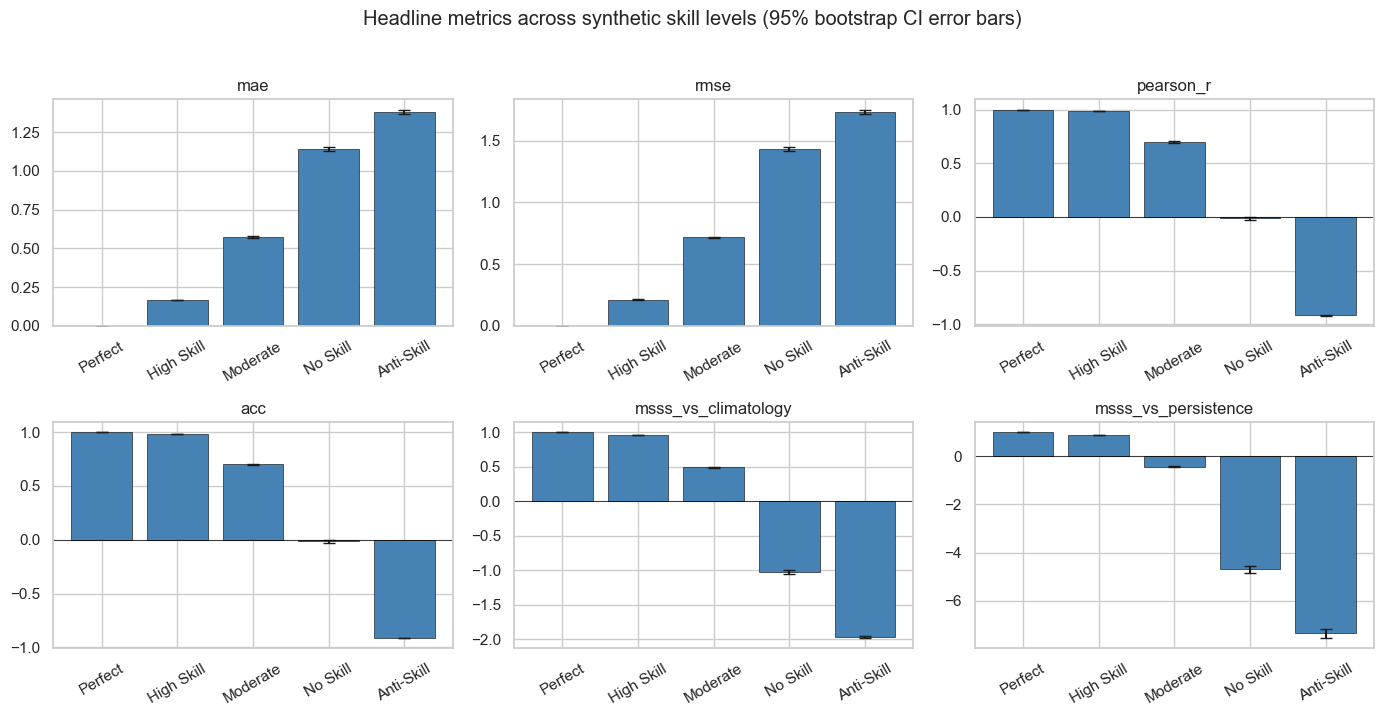

In [9]:
headline = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, metric in zip(axes.flatten(), headline):
    sub = results_df[results_df['metric'] == metric]
    skill_levels = sub['model'].str.replace('synthetic_', '').str.replace('_', ' ').str.title()
    ax.bar(skill_levels, sub['value'], yerr=[sub['value'] - sub['ci_lower'], sub['ci_upper'] - sub['value']],
           capsize=4, color='steelblue', edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Headline metrics across synthetic skill levels (95% bootstrap CI error bars)', y=1.02)
plt.tight_layout()
save_figure(fig, 'headline_metrics_by_skill', subdir=FIG_SUBDIR)
plt.show()

## Notes

- **CI tightness with N**: at 16,400 samples (100 months × 164 cells) the CIs above are very tight (σ ≈ 0.002 for MAE/RMSE). In the real pipeline, the **effective** sample size is closer to 100 (time steps), since cells are spatially correlated. The block bootstrap respects time but not space — expect wider CIs in practice unless we also account for spatial dependence.
- **Why MSSS vs persistence can be negative for the "No skill" case**: persistence is constructed here as `truth + 0.6·noise`, which is already a fairly good predictor (small noise). A purely random prediction will be much worse than persistence → strongly negative MSSS.
- **MSSS vs climatology ≈ 0 for the No-skill case**: random noise has the same MSE as random noise, so neither is informative; ratio ≈ 1 → MSSS ≈ 0.
- **HSS sample size warning**: at SPEI3 < −1.0, only ~16 % of points are droughts (here ~2,600 of 16,400). Per-fold (20 winter months × 164 cells = 3,280) it's ~525 drought events — enough for a stable HSS estimate. At more extreme thresholds (−1.5 or −2.0) the events become rare and HSS will be noisy.
- **What's next (Phase 5)**: implement the actual baselines (climatology, persistence, AR(p)) and feed real predictions through this same reporter — the same plots above become the *first real results*.